In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
import seaborn as sns


In [3]:
DATASET_DIR = "Downloads/nail_disease_dataset/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_INITIAL = 15
EPOCHS_FINE = 10


In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)


Found 939 images belonging to 3 classes.
Found 233 images belonging to 3 classes.
Classes: ['healthy', 'onychomycosis', 'psoriasis']


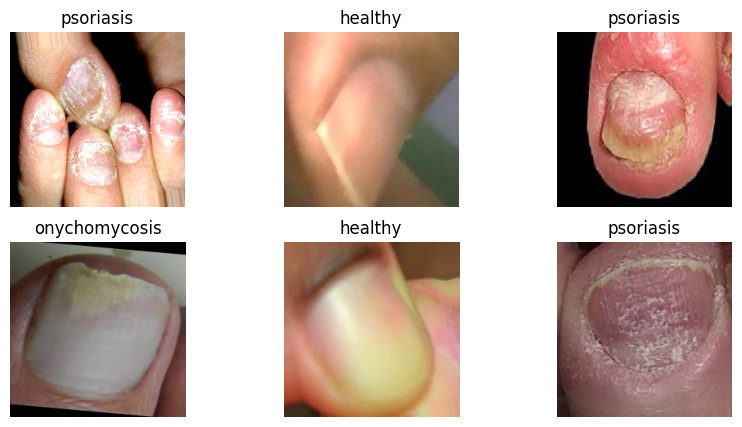

In [5]:
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.show()


In [6]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)


In [7]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False


In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [10]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_INITIAL
)


Epoch 1/15
59/59 [==============================] - 85s 1s/step - loss: 0.5965 - accuracy: 0.7391 - val_loss: 1.3082 - val_accuracy: 0.5064
Epoch 2/15
59/59 [==============================] - 51s 860ms/step - loss: 0.3064 - accuracy: 0.8765 - val_loss: 1.0479 - val_accuracy: 0.6052
Epoch 3/15
59/59 [==============================] - 56s 947ms/step - loss: 0.2037 - accuracy: 0.9223 - val_loss: 0.7530 - val_accuracy: 0.7210
Epoch 4/15
59/59 [==============================] - 53s 899ms/step - loss: 0.1272 - accuracy: 0.9510 - val_loss: 0.6382 - val_accuracy: 0.7854
Epoch 5/15
59/59 [==============================] - 56s 954ms/step - loss: 0.1307 - accuracy: 0.9542 - val_loss: 0.5478 - val_accuracy: 0.7983
Epoch 6/15
59/59 [==============================] - 75s 1s/step - loss: 0.0954 - accuracy: 0.9702 - val_loss: 0.5148 - val_accuracy: 0.8455
Epoch 7/15
59/59 [==============================] - 62s 1s/step - loss: 0.0741 - accuracy: 0.9744 - val_loss: 0.5756 - val_accuracy: 0.8455
Epoch 8/

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FINE
)


Epoch 1/10
59/59 [==============================] - 70s 976ms/step - loss: 0.0266 - accuracy: 0.9925 - val_loss: 0.4326 - val_accuracy: 0.8755
Epoch 2/10
59/59 [==============================] - 55s 935ms/step - loss: 0.0305 - accuracy: 0.9872 - val_loss: 0.3598 - val_accuracy: 0.8755
Epoch 3/10
59/59 [==============================] - 56s 942ms/step - loss: 0.0261 - accuracy: 0.9904 - val_loss: 0.3456 - val_accuracy: 0.8927
Epoch 4/10
59/59 [==============================] - 55s 927ms/step - loss: 0.0333 - accuracy: 0.9894 - val_loss: 0.3301 - val_accuracy: 0.8970
Epoch 5/10
59/59 [==============================] - 61s 1s/step - loss: 0.0163 - accuracy: 0.9957 - val_loss: 0.2924 - val_accuracy: 0.9099
Epoch 6/10
59/59 [==============================] - 68s 1s/step - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.3560 - val_accuracy: 0.8712
Epoch 7/10
59/59 [==============================] - 60s 1s/step - loss: 0.0194 - accuracy: 0.9957 - val_loss: 0.3995 - val_accuracy: 0.9056
Epoch 8/

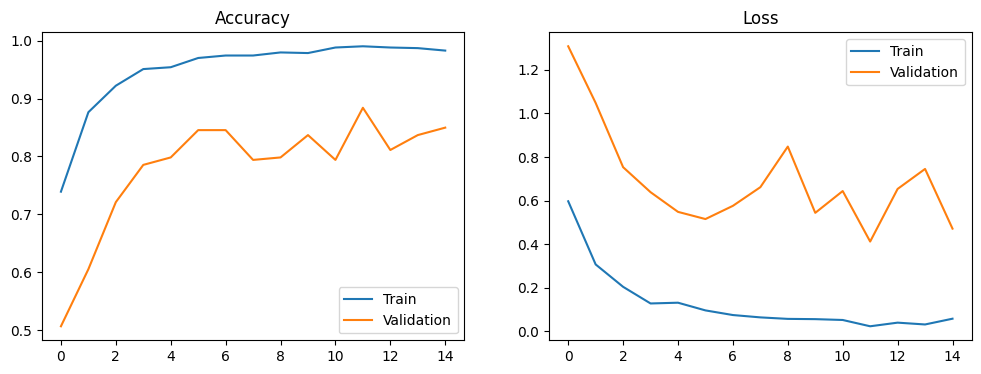

In [18]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history1.history["accuracy"], label="Train")
plt.plot(history1.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history1.history["loss"], label="Train")
plt.plot(history1.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()


In [20]:
from tensorflow.keras.preprocessing import image

def safe_predict_nail(img_path, threshold=0.7):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    top_idx = preds.argsort()[::-1]

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("🔬 Prediction Probabilities:")
    for i in top_idx[:3]:
        print(f"{class_names[i]} : {preds[i]*100:.2f}%")

    if preds[top_idx[0]] < threshold:
        print("\n⚠️ Final Decision: Uncertain – Clinical review required")
    else:
        print(f"\n✅ Final Diagnosis: {class_names[top_idx[0]]}")


1/1 [==============================] - 1s 1s/step


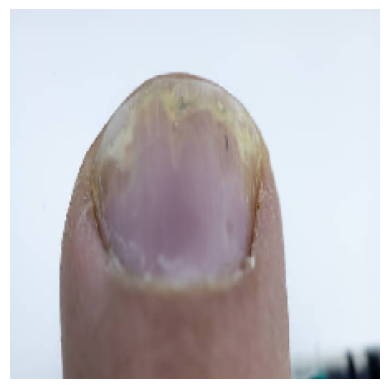

🔬 Prediction Probabilities:
psoriasis : 99.77%
onychomycosis : 0.23%
healthy : 0.01%

✅ Final Diagnosis: psoriasis


In [21]:
safe_predict_nail("Downloads/nail_disease_dataset/psoriasis/3.jpg")


In [22]:
val_data.reset()

y_true = []
y_pred = []
y_prob = []

for i in range(len(val_data)):
    images, labels = val_data[i]
    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


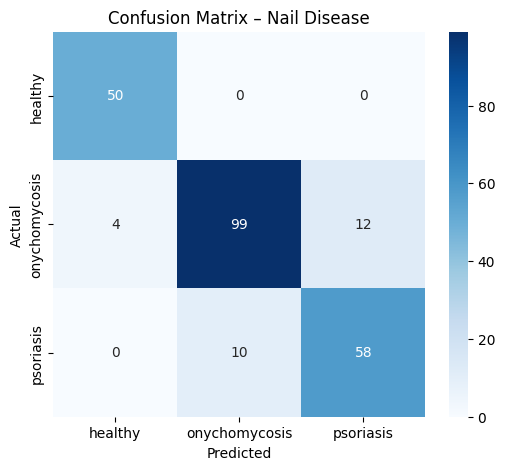

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Nail Disease")
plt.show()


In [24]:
print(classification_report(
    y_true, y_pred,
    target_names=class_names
))


               precision    recall  f1-score   support

      healthy       0.93      1.00      0.96        50
onychomycosis       0.91      0.86      0.88       115
    psoriasis       0.83      0.85      0.84        68

     accuracy                           0.89       233
    macro avg       0.89      0.90      0.90       233
 weighted avg       0.89      0.89      0.89       233



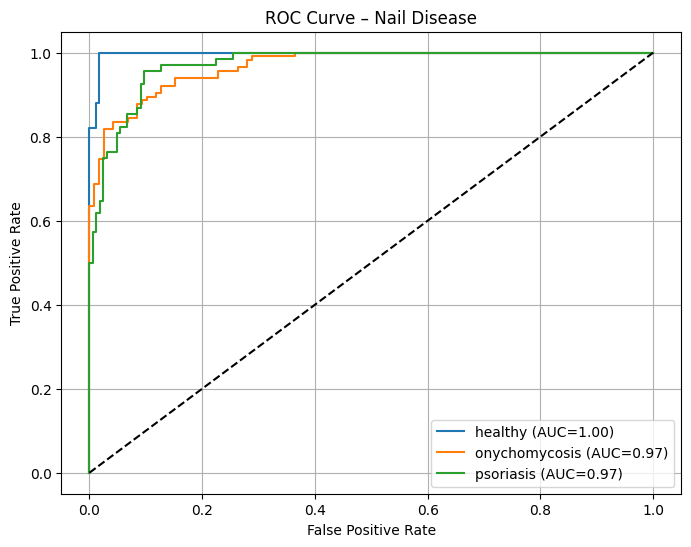

In [25]:
plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Nail Disease")
plt.legend()
plt.grid()
plt.show()


In [26]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

results


,Metric,Score
0,Accuracy,0.888412
1,Precision,0.888793
2,Recall,0.888412
3,F1-Score,0.887932
